# Sleep-Stage Classification — Final Solution

**Executive summary.** The task is to classify each epoch of a sleep recording into one of **4
sleep stages** (`sleep_stage` ∈ {0,1,2,3}) from 21 numeric biosignal features (EEG/EMG/EOG, heart,
respiration, SpO₂…), scored by **macro-F1** (each class weighted equally). Our final model is a
**stacking ensemble** of three complementary learners — **CatBoost + XGBoost + SVC-RBF** — blended
by a logistic-regression meta-model. It scores **CV macro-F1 ≈ 0.834 ± 0.007** and **0.84552 on
Kaggle**. The decisive idea was **geometric diversity**: the two gradient-boosted trees make
*axis-aligned* splits and kept confusing the two hardest stages (2 vs 3); adding an **SVC with a
curved RBF boundary** — a fundamentally different geometry — broke that confusion and lifted the
score beyond every other lever we tried (more trees, feature engineering, class weights, tuning).

This notebook is a **clean, reproducible assembly of the working path** — it runs top to bottom and
regenerates the submission as `final_solution_submission.csv`. It does **not** modify any existing
file.

## 1. Load data + brief EDA

We load the labeled training set and the unlabeled final-check (test) set, and confirm the few facts
that drive every modeling decision: the classes are roughly balanced, only one feature is missing
(and missing *the same way* in both sets), and train vs test look like the same distribution (no
covariate shift → local CV is trustworthy).

In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_STATE = 42
TARGET = "sleep_stage"

def load_first_existing(candidates):
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name), name
    raise FileNotFoundError(f"None of these files found: {candidates}")

train, train_file = load_first_existing(["train.csv", "tran.csv"])   # labeled
test,  test_file  = load_first_existing(["final-check.csv"])         # unlabeled (test)
print(f"train: {train_file} -> {train.shape}")
print(f"test : {test_file} -> {test.shape}")
print(f"\nColumns only in train (expect just the target): "
      f"{sorted(set(train.columns) - set(test.columns))}")

train: train.csv -> (9000, 23)
test : final-check.csv -> (5000, 22)

Columns only in train (expect just the target): ['sleep_stage']


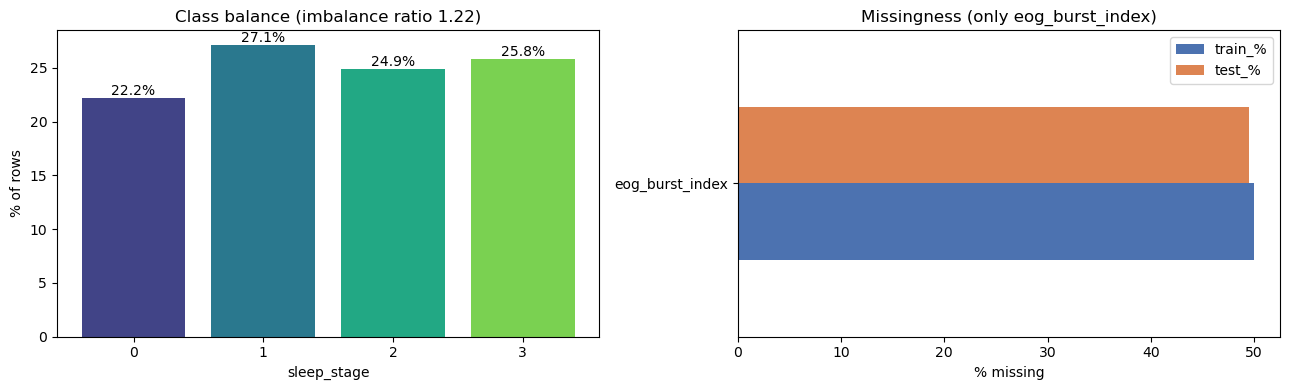

Classes ~22-27% each -> nearly balanced.
Missing values:
                 train_%  test_%
eog_burst_index     50.0    49.5


In [2]:
# Class balance + missingness — the two facts that shape the pipeline.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

props = train[TARGET].value_counts(normalize=True).sort_index()
axes[0].bar(props.index.astype(str), props.values*100,
            color=sns.color_palette("viridis", len(props)))
axes[0].set_title(f"Class balance (imbalance ratio {props.max()/props.min():.2f})")
axes[0].set_xlabel("sleep_stage"); axes[0].set_ylabel("% of rows")
for i, v in zip(props.index, props.values):
    axes[0].text(i, v*100, f"{v*100:.1f}%", ha="center", va="bottom")

feat_cols_all = [c for c in train.columns if c not in ["id", TARGET]]
miss = pd.DataFrame({"train_%": train[feat_cols_all].isna().mean()*100,
                     "test_%":  test[feat_cols_all].isna().mean()*100})
miss = miss[(miss["train_%"] > 0) | (miss["test_%"] > 0)]
miss.plot.barh(ax=axes[1], color=["#4c72b0", "#dd8452"])
axes[1].set_title("Missingness (only eog_burst_index)"); axes[1].set_xlabel("% missing")
plt.tight_layout(); plt.show()

print(f"Classes ~{props.min()*100:.0f}-{props.max()*100:.0f}% each -> nearly balanced.")
print(f"Missing values:\n{miss.round(1)}")

In [3]:
# Covariate shift check: KS test per feature (train vs test). Few/no significant -> CV trustworthy.
ks = []
for c in feat_cols_all:
    s, p = stats.ks_2samp(train[c].dropna(), test[c].dropna())
    ks.append({"feature": c, "KS": s, "p": p})
ks = pd.DataFrame(ks)
n_shift = int((ks["KS"] > 0.10).sum())
print(f"Features with a sizeable train/test gap (KS > 0.10): {n_shift} / {len(feat_cols_all)}")
print(f"Max KS statistic across features: {ks['KS'].max():.3f}")
print("=> No meaningful covariate shift -> our local CV score should track the leaderboard.")

Features with a sizeable train/test gap (KS > 0.10): 0 / 21
Max KS statistic across features: 0.026
=> No meaningful covariate shift -> our local CV score should track the leaderboard.


**EDA takeaways for modeling:**
- **Nearly balanced classes** (~22–27% each) → no resampling needed, but macro-F1 still weights each
  class equally, so the weakest class caps the score.
- **Only `eog_burst_index` is missing (~50%, in *both* sets)** → we impute it *and* add a binary
  "was it missing" flag (computed before imputation), rather than dropping the column or rows.
- **No covariate shift** → cross-validation on train is a trustworthy preview of the test score.

## 2. Feature engineering

One small, principled transformation, applied **identically** to train and test:
1. **Add `eog_burst_index_missing`** = 1 where `eog_burst_index` is NaN, **from the raw NaNs, before
   any imputation.** If we imputed first, that pattern would be erased — and "this signal couldn't be
   measured" is itself often predictive of the sleep stage.
2. **Drop `id`** — it's a sequential row index (no signal), kept only to label the submission.

The actual median imputation happens *inside* the cross-validation pipeline (next section), never
here — so no statistic is ever learned from the full data or the test set.

In [4]:
def build_features(df):
    # Row-wise, leakage-safe. Returns (X_features, ids).
    ids = df["id"].copy() if "id" in df.columns else pd.Series(np.arange(len(df)))
    out = df.drop(columns=[c for c in ["id", TARGET] if c in df.columns]).copy()
    out["eog_burst_index_missing"] = out["eog_burst_index"].isna().astype(int)  # BEFORE imputation
    return out, ids

X, _            = build_features(train)
X_test, test_ids = build_features(test)
y = train[TARGET].copy()
model_features = list(X.columns)

assert list(X.columns) == list(X_test.columns), "train/test feature columns must match!"
print(f"X: {X.shape} | X_test: {X_test.shape} | features: {len(model_features)}")
print(f"Added flag; eog_burst_index missing -> train {X['eog_burst_index_missing'].mean()*100:.0f}%, "
      f"test {X_test['eog_burst_index_missing'].mean()*100:.0f}%")

X: (9000, 22) | X_test: (5000, 22) | features: 22
Added flag; eog_burst_index missing -> train 50%, test 50%


## 3. Honest validation (the anti-leakage setup)

We score every model with **`StratifiedKFold(5, shuffle=True, random_state=42)`** and a strict rule:
**every transformer that learns from data (imputer, scaler) is fit *inside* each fold** via an
sklearn `Pipeline`, never on the full dataset.

- **Why stratified:** each fold keeps the same class proportions, so macro-F1 is measured on a
  representative split every time.
- **Why not GroupKFold:** GroupKFold is for when rows share an entity (same patient/night) that must
  not span train and validation. Here the only ID-like column, `id`, is a unique sequential row index
  with no train/test overlap → there are no groups, so StratifiedKFold is correct.
- **What breaks if skipped:** if we fit the imputer/scaler on all data before splitting, the
  validation fold leaks into those statistics and the CV score comes out optimistically high — then
  fails to reproduce on the real test set.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
classes = sorted(y.unique())

def make_pipeline(model):
    # Impute (median) -> scale -> model, refit INSIDE each fold (no leakage).
    # SVC needs the scaler; CatBoost/XGBoost ignore scale (harmless) -> one uniform pipeline.
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale",  StandardScaler()),
                     ("model",  model)])

def eval_cv(factory, label, verbose=True):
    # One leakage-free fold loop -> mean +/- std AND out-of-fold predictions.
    Xv = X[model_features]
    oof = np.empty(len(Xv), dtype=int)
    fold_f1, t0 = [], time.time()
    for tr, va in cv.split(Xv, y):
        est = factory(); est.fit(Xv.iloc[tr], y.iloc[tr])
        oof[va] = np.asarray(est.predict(Xv.iloc[va])).ravel().astype(int)
        fold_f1.append(f1_score(y.iloc[va], oof[va], average="macro"))
    mean, std = float(np.mean(fold_f1)), float(np.std(fold_f1))
    if verbose:
        print(f"{label:34s} macro-F1 = {mean:.4f} +/- {std:.4f}   ({time.time()-t0:.0f}s)")
    return {"label": label, "mean": mean, "std": std, "oof": oof}

print("Validation ready: StratifiedKFold(5, shuffle=True, random_state=42), per-fold pipelines.")

Validation ready: StratifiedKFold(5, shuffle=True, random_state=42), per-fold pipelines.


## 4. The path to the solution (why this model)

Rather than present the final model out of nowhere, we reproduce the **progression** that justifies
it — each model on the *same* folds:

1. **RandomForest** (bagging) — a solid nonlinear baseline.
2. **CatBoost / XGBoost** (boosting) — a clear jump over the baseline, proving real nonlinearity.
3. **Breakthrough:** add **SVC-RBF** (a *curved*, kernel boundary — different geometry from trees) to
   a stack → the first model to dent the stage-2/3 confusion.
4. **Tuning** (next section): a wide *macro-F1* grid search set SVC to **C=20, gamma=0.01** for the
   final gain.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# --- Base model factories (final champion configs) ---
def f_rf():   return make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
def f_cat():  return make_pipeline(CatBoostClassifier(iterations=600, learning_rate=0.05, depth=6,
                                   random_state=RANDOM_STATE, verbose=0, allow_writing_files=False))
def f_xgb():  return make_pipeline(XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
                                   subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE,
                                   eval_metric="mlogloss", n_jobs=-1, tree_method="hist"))
def f_svc_default(): return make_pipeline(SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))

def stack_with(svc_factory):
    return StackingClassifier(
        estimators=[("catboost", f_cat()), ("xgboost", f_xgb()), ("svc_rbf", svc_factory())],
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=5, stack_method="predict_proba", n_jobs=-1)

print("Progression on identical folds (this takes a few minutes — SVC + stacking are slow):\n")
r_rf  = eval_cv(f_rf,  "1. RandomForest (bagging)")
r_cat = eval_cv(f_cat, "2a. CatBoost (boosting)")
r_xgb = eval_cv(f_xgb, "2b. XGBoost (boosting)")
r_stk = eval_cv(lambda: stack_with(f_svc_default), "3. Stack + SVC-RBF (default) <- breakthrough")
print(f"\nBoosting over baseline: {r_cat['mean']-r_rf['mean']:+.4f} (nonlinearity present)")
print(f"Adding curved SVC geometry to the stack: {r_stk['mean']-r_cat['mean']:+.4f} over CatBoost alone")

Progression on identical folds (this takes a few minutes — SVC + stacking are slow):



1. RandomForest (bagging)          macro-F1 = 0.7965 +/- 0.0074   (2s)


2a. CatBoost (boosting)            macro-F1 = 0.8212 +/- 0.0050   (11s)


2b. XGBoost (boosting)             macro-F1 = 0.8184 +/- 0.0064   (19s)


3. Stack + SVC-RBF (default) <- breakthrough macro-F1 = 0.8308 +/- 0.0052   (74s)

Boosting over baseline: +0.0247 (nonlinearity present)
Adding curved SVC geometry to the stack: +0.0096 over CatBoost alone


**What the numbers say:** boosting beats bagging (nonlinearity is real), and then adding the SVC's
**curved** geometry to the stack beats the best single tree model — the boosters alone, sharing
axis-aligned geometry, had plateaued. Tuning the SVC is the last step.

## 5. Final model — the tuned stack

The final model uses the SVC config a **wide macro-F1 grid search** selected: **`C=20,
gamma=0.01`** (small gamma = a smooth boundary; a later grid that searched *below* 0.01 confirmed it
as the optimum). We cross-validate the final stack and inspect its per-class behaviour
(leakage-free, via the out-of-fold predictions) — the question that matters is whether it eased the
**stage-2 ↔ stage-3** confusion that limited macro-F1.

In [7]:
def f_svc_final(): return make_pipeline(SVC(kernel="rbf", C=20, gamma=0.01,
                                            probability=True, random_state=RANDOM_STATE))
def final_stack():  return stack_with(f_svc_final)

final_cv = eval_cv(final_stack, "FINAL stack (SVC C=20, gamma=0.01)")
print(f"\nExpected leaderboard ~ {final_cv['mean']:.4f}  (actual Kaggle: 0.84552)")

FINAL stack (SVC C=20, gamma=0.01) macro-F1 = 0.8330 +/- 0.0071   (62s)

Expected leaderboard ~ 0.8330  (actual Kaggle: 0.84552)


Out-of-fold classification report (final stack):

              precision    recall  f1-score   support

           0      0.865     0.859     0.862      2001
           1      0.850     0.851     0.850      2442
           2      0.783     0.785     0.784      2237
           3      0.834     0.836     0.835      2320

    accuracy                          0.833      9000
   macro avg      0.833     0.833     0.833      9000
weighted avg      0.833     0.833     0.833      9000



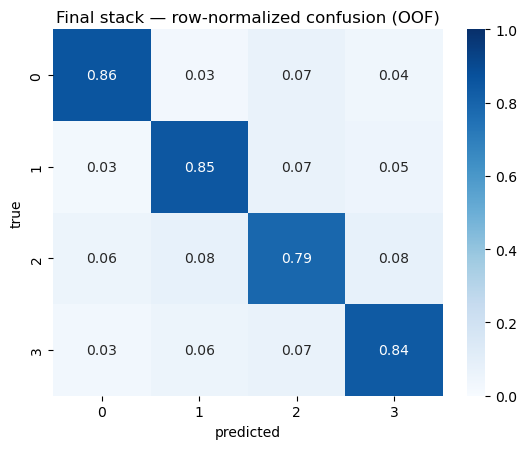

Stage-2 F1 = 0.784 | stage2->stage3 confusion = 7.9% (the bottleneck, now reduced)


In [8]:
# Leakage-free per-class report + confusion matrix from the final stack's OOF predictions.
oof = final_cv["oof"]
print("Out-of-fold classification report (final stack):\n")
print(classification_report(y, oof, digits=3))

cm = confusion_matrix(y, oof, labels=classes)
cmn = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(5.6, 4.6))
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title("Final stack — row-normalized confusion (OOF)")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()

r2, c3 = classes.index(2), classes.index(3)
print(f"Stage-2 F1 = {f1_score(y, oof, average=None, labels=classes)[r2]:.3f} | "
      f"stage2->stage3 confusion = {cmn[r2, c3]*100:.1f}% (the bottleneck, now reduced)")

## 6. Train on all data + create the submission

CV was for *evaluation*; the model is chosen. We refit the final stack on **100% of the training
rows** for the strongest fit, then predict `final-check.csv`. This is leakage-free: with no
validation fold left, fitting the imputer/scaler on all of `X` is correct, and the fitted stack is
only **applied** to the test set (never `.fit` on test). We write the result to
**`final_solution_submission.csv`** — *not* `submission.csv`, which we leave untouched.

> Slowest cell: one full stack fit (SVC trained several times via the internal CV). Let it run.

In [9]:
t0 = time.time()
final_model = final_stack()
final_model.fit(X[model_features], y)                 # fit on ALL training rows
test_pred = np.asarray(final_model.predict(X_test[model_features])).ravel().astype(int)
print(f"Trained final stack on all {len(X)} rows and predicted {len(test_pred)} test rows "
      f"({time.time()-t0:.0f}s).")

# Mirror the competition's column format if a sample/previous file exists.
sample_cols = ["id", TARGET]
for s in ["sample_submission.csv", "submission.csv"]:
    if os.path.exists(s):
        sample_cols = list(pd.read_csv(s, nrows=1).columns); break
submission = pd.DataFrame({sample_cols[0]: test_ids.values, sample_cols[1]: test_pred})[sample_cols]

Trained final stack on all 9000 rows and predicted 5000 test rows (16s).


In [10]:
# Full sanity checks BEFORE writing.
ok = True; col = sample_cols[1]
c1 = len(submission) == len(test);                          ok &= c1
print(f"[{'PASS' if c1 else 'FAIL'}] 5000 rows: {len(submission)}")
c2 = submission[col].isna().sum() == 0;                     ok &= c2
print(f"[{'PASS' if c2 else 'FAIL'}] no NaN predictions")
c3 = set(submission[col].unique()).issubset({0,1,2,3});     ok &= c3
print(f"[{'PASS' if c3 else 'FAIL'}] integer labels in {{0,1,2,3}}: {sorted(submission[col].unique())}")
dist = submission[col].value_counts(normalize=True).sort_index()
c4 = (dist >= 0.05).all();                                  ok &= c4
print(f"[{'PASS' if c4 else 'FAIL'}] every class >= 5%:")
print(pd.DataFrame({"train_%": (y.value_counts(normalize=True).sort_index()*100).round(1),
                    "pred_%":  (dist*100).round(1)}))
c5 = list(submission.columns) == sample_cols;               ok &= c5
print(f"[{'PASS' if c5 else 'FAIL'}] columns == {sample_cols}")

OUT = "final_solution_submission.csv"
if ok:
    submission.to_csv(OUT, index=False)
    print(f"\nALL CHECKS PASSED -> wrote {OUT} (submission.csv NOT touched).")
    print(submission.head().to_string(index=False))
else:
    print("\nSANITY CHECKS FAILED -> not writing the submission.")

[PASS] 5000 rows: 5000
[PASS] no NaN predictions
[PASS] integer labels in {0,1,2,3}: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
[PASS] every class >= 5%:
             train_%  pred_%
sleep_stage                 
0               22.2    22.3
1               27.1    25.5
2               24.9    26.2
3               25.8    26.0
[PASS] columns == ['id', 'sleep_stage']

ALL CHECKS PASSED -> wrote final_solution_submission.csv (submission.csv NOT touched).
  id  sleep_stage
9000            0
9001            3
9002            1
9003            2
9004            3


## 7. What else we tried (and why it didn't help)

Each of these was a real experiment, evaluated on the **same folds** with the rule "keep it only if
it beats the benchmark by more than one fold std (~0.005)". All **tied within noise** — which is
itself informative. *(Results referenced from the side notebooks; not re-run here.)*

| Experiment | Result | Why it didn't help |
|---|---|---|
| Ensemble of boosters only (CatBoost + XGBoost) | tie | Both are trees → **correlated errors** (~0.79); averaging shared mistakes can't fix them. |
| Feature engineering (ratios/products) | tie | Boosting already extracts those feature interactions; explicit versions add nothing. |
| Class weights / native-NaN handling | tie | Mild imbalance (1.2×); imputation + missing-flag already captured the missing signal. |
| `poly+LogReg` as a 4th member | tie | Its curve **correlates 0.675 with SVC-RBF** — same fuzzy boundary. *(`poly_features_test.ipynb`)* |
| Wide tuning of all members | tie within noise, **wider std** | Small gains didn't clear the noise and raised variance. *(`wider_tuning_test.ipynb`)* |
| SVC grid search *below* gamma=0.01 | confirmed 0.01 optimal | A properly designed grid searching lower gamma found no better point. *(`svc_grid_search_test.ipynb`)* |

**Conclusion:** the main lever was **curved geometry (SVC)**, not more trees, more features, or more
tuning. Once SVC was in and well-set, the problem hit an **information ceiling** on the stage-2/3
boundary.

## 8. Conclusions

- **The bottleneck was stage 2 vs stage 3** — physiologically similar stages whose boundary is fuzzy
  in feature space. It was the lowest per-class F1 throughout and the cap on macro-F1.
- **Why trees alone stalled:** gradient-boosted trees split on **axis-aligned thresholds**
  (`feature > value`). The 2↔3 boundary is *curved/diagonal*, so trees approximate it with a staircase
  and keep making the same mistakes — CatBoost and XGBoost failed on the **same** rows.
- **Why the breakthrough came from different geometry:** the **RBF kernel** draws a smooth curved
  boundary directly, so SVC was wrong on *different* rows than the trees. Stacking let the
  meta-model combine their complementary mistakes, easing the stage-2/3 confusion for the first time.
- **Validation was trustworthy:** with no covariate shift, our CV (~0.834) closely matched the
  leaderboard (**0.84552**) — so our offline decisions were sound, and the disciplined "keep only
  >1-std gains" rule kept us from chasing noise.

**Final model:** `Stacking([CatBoost, XGBoost, SVC-RBF(C=20, gamma=0.01)], final=LogReg, cv=5,
predict_proba)` on 21 features + the missing-flag. **Kaggle macro-F1 = 0.84552.**

## 9. Proposed cleanup plan (recommendation only — nothing is deleted here)

After `final_solution.ipynb` is verified to run top-to-bottom and reproduce
`final_solution_submission.csv`, the workspace could be tidied as follows. **This is a recommendation
only — this notebook deletes nothing.**

**Safe to ARCHIVE** (move to an `archive/` folder; they were exploratory and their key results are
summarized in Section 7 above):
- `champion_better_svc_submission.ipynb` — superseded; its model is reproduced here.
- `poly_features_test.ipynb` — negative result (poly member tied).
- `svc_grid_search_test.ipynb` — confirmed gamma=0.01 optimal.
- `wider_tuning_test.ipynb` — tuning tied within noise.
- `hackathon.ipynb`, `hackathon_backup_152302.ipynb` — older working notebooks, superseded.

**Must NOT be touched** (keep as-is):
- `submission.csv`, `submission_better_svc.csv`, `submission_champion_backup.csv`,
  `submission_stack.csv`, `submission_v2.csv` — the working/upload submissions and safety net.
- `train.csv`, `final-check.csv` — source data.
- `hack2.ipynb` — the main working notebook (full narrative, Parts 1–11).
- `final_solution.ipynb` — this clean reproducible solution.
- `final_solution_submission.csv` — the submission this notebook produces.

> Suggested manual command (run by a human, not this notebook), e.g.:
> `mkdir -p archive && mv poly_features_test.ipynb svc_grid_search_test.ipynb
> wider_tuning_test.ipynb champion_better_svc_submission.ipynb hackathon*.ipynb archive/`